# SCRP toolkit walkthrough (PG-S2-32)

Each step checks one part of the toolkit against the matching part of RYA's Box folder, runs it on the customer's data, and says what to expect.

**How to run**
1. Open this notebook from the repo root (the folder with `README.md`), kernel **Python (scrp)**.
2. Nothing to edit if the data is in the repo's `./data`. Otherwise put your paths in `local_settings.py` (see SETTINGS below).
3. *Restart* → *Run All*. The whole notebook takes about 5–7 minutes.

The **SETTINGS** and **SETUP** cells must run first. After that, any step can be re-run on its own.

| Step | File | Checked against RYA's version |
|---|---|---|
| 1 | environment | packages RYA's code imports |
| 2 | `config.py` | the 9 input files, byte-for-byte (SHA-1) |
| 3 / 3b | `reliability.py` | `unreliability-matrices.json`, `asymm_calc`, Heatmaps, `P.RData`, training data |
| 4 | `features.py` | `feature_calculation_portal_script.py` + R's features in the training CSVs |
| 5 | `inference.py` | portal `normalise` / `reverse_normalise` + the ONNX model |
| 6 | `dataset.py` | `net_dataset_init_B.py` (run live) + `EXP002.json` scaling |
| 7 | `model.py` | the ONNX model's weights + `misc_functions.K/KL` |
| 8 | `scoring.py` | a real RY25 school, recorded baseline|
| 9 | `cli.py`, `baseline.py`, tests, `edge_cases.py` | everything at once. 359 checks in total |

## SETTINGS: where every path and choice comes from

All settings live in one file, **`scrp_toolkit/settings.py`**, shared by this notebook and the command-line tool.

**To set your own paths:** copy `local_settings.example.py` to `local_settings.py` and change what you need, usually just `DATA_DIR`. That file stays on your computer: git ignores it, so it never clashes with any other teammate's work.

This cell reads the settings and prints them. To try something different for this notebook only, override a value at the bottom of the cell.

In [44]:
import sys, os
from pathlib import Path

REPO_DIR = Path.cwd()                                # the folder containing README.md
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
from scrp_toolkit import settings                   # defaults + your local_settings.py

DATA_DIR      = settings.DATA_DIR                   # customer Box files
REPORT_CSV    = settings.REPORT_CSV                 # Step 9: one row per baseline check
EDGE_CASE_DIR = settings.EDGE_CASE_DIR              # Step 9: edge-case files for input classifier
EXAMPLE_ITEM, EXAMPLE_PRE, EXAMPLE_POST = settings.EXAMPLE_ITEM, settings.EXAMPLE_PRE, settings.EXAMPLE_POST
SPLIT_SEED, TRAIN_FRAC  = settings.SPLIT_SEED, settings.TRAIN_FRAC
CHECK_ALL_TRAINING_ROWS = settings.CHECK_ALL_TRAINING_ROWS   # Step 4
RUN_TRAINING_DEMO       = settings.RUN_TRAINING_DEMO         # Step 9
CORRUPT_ROW             = settings.CORRUPT_ROW

# Override for this notebook only if required. Otherwise, set DATA_DIR in local_settings.py.
# DATA_DIR = Path(r"D:\Desktop\Academics\Sem-2-26\Claude\data")

print("settings file :", Path(settings.__file__))
print("your overrides:", REPO_DIR / "local_settings.py", "(found)" if (REPO_DIR / "local_settings.py").is_file() else "(none, using defaults)")
print("data          :", DATA_DIR, "(found)" if Path(DATA_DIR).is_dir() else "<-- NOT FOUND: set DATA_DIR in local_settings.py")

settings file : d:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\scrp_toolkit\settings.py
your overrides: d:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\local_settings.py (none, using defaults)
data          : D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data (found)


## SETUP: shared objects (run once, after SETTINGS)

Loads all file locations, the unreliability matrices, the model and its metadata, RYA's native functions from the shared files of their code, and a helper for `P.RData`.No computation here. Only sanity checks.

In [2]:
import sys, io, json, ast, types, builtins, glob, time, subprocess, warnings
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display

assert (REPO_DIR / "scrp_toolkit").is_dir(), "Open this notebook from the repo root (next to README.md)."
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from scrp_toolkit.config import resolve_project_paths
from scrp_toolkit.reliability import load_p_matrices
from scrp_toolkit.inference import UnreliabilityPredictor

DATA = str(DATA_DIR)
paths = resolve_project_paths(DATA)
P = load_p_matrices(paths.pmatrices_path)               # {item: matrix}
meta = json.load(open(paths.metadata_path))             # EXP002.json
stored_mm = pd.read_json(io.StringIO(meta["min_max_df"])).set_index("column")   # EXP002's scaling
predictor = UnreliabilityPredictor(paths)               # ONNX model + scaling
x, y = np.array(EXAMPLE_PRE), np.array(EXAMPLE_POST)

def box_file(name):
    """Path of a file from Box's 'Final code' folder inside DATA_DIR."""
    hits = sorted(Path(DATA).rglob(name))
    assert hits, f"{name} not found under {DATA}"
    return hits[0]

def load_rya(fname, names=None, extra=None):
    """Run functions/classes from one of RYA's Box files, unchanged.

    Only their imports and definitions are executed. Their top-level lines open files on
    Liam's Mac (/Users/liam/...), which don't exist here."""
    tree = ast.parse(box_file(fname).read_text())
    keep = [n for n in tree.body
            if isinstance(n, (ast.FunctionDef, ast.ClassDef)) and (names is None or n.name in names)]
    ns = {"np": np, "pd": pd, "ast": ast, "torch": torch, **(extra or {})}
    exec(compile(ast.Module(body=keep, type_ignores=[]), fname, "exec"), ns)
    return ns

# RYA's portal functions (extract_features, normalise, reverse_normalise, ...); they read a global P_matrices
rya = load_rya("feature_calculation_portal_script.py",
               extra={"P_matrices": {q: m.tolist() for q, m in P.items()}})

def load_p_rdata():
    """RYA's P.RData (used by their R simulation) as {item: matrix}.

    Read with scrp_toolkit's own small R-file reader: no extra package to install."""
    from scrp_toolkit.rds import read_rds
    return {k: np.asarray(v, dtype=float) for k, v in read_rds(box_file("P.RData")).items()}

print(f"SETUP done: {len(P)} matrices, model '{predictor.describe()}'")

SETUP done: 59 matrices, model 'Model: 20 layers, width 256, 40 features, P_transform='all_P_asymm''


## Step 1: Environment check

**Why:** RYA's original code only ran on their machines, because every file in Box → *Final code* has `/Users/liam/...` or `/home/ubuntu/...` paths written into it. A shared conda env (`scrp`, Python 3.11) means everyone runs the same packages.

| RYA's code imports | Ours | Why |
|---|---|---|
| numpy, pandas, torch | same | features, model, data loading |
| `torch.onnx.export` (`perform_exp.py`) | `onnxruntime` + `onnx` | RYA *wrote* the ONNX model; we only *read* it |
| seaborn, matplotlib | same | plots only |
| torchvision, torch.multiprocessing | not used | imported by RYA but never used by the code we need |

**Expect:** Python 3.11.x and the package versions, no errors.

In [3]:
import onnxruntime, onnx, scrp_toolkit
print("Python     ", sys.version.split()[0])
for mod in (np, pd, torch, onnxruntime, onnx):
    print(f"{mod.__name__:11}", mod.__version__)
print("\nscrp_toolkit found at", Path(scrp_toolkit.__file__).parent)

Python      3.11.16
numpy       2.4.6
pandas      3.0.6
torch       2.14.0+cpu
onnxruntime 1.30.0
onnx        1.23.0

scrp_toolkit found at d:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\scrp_toolkit


## Step 2: `config.py`, finding the data files

**Why:** Every later step needs the same 9 input files. `config.py` finds them by file name inside `DATA_DIR`, whatever the sub-folder names

**Compared with *Final code*:** RYA hard-coded paths to their own machines:

| RYA file | Hard-coded path | Loads |
|---|---|---|
| `feature_calculation_portal_script.py` | `/Users/liam/.../P_matrices_test.json`, `.../EXP003.json` | a *test* matrices file and **EXP003** metadata, i.e. development leftovers |
| `net_dataset_init_B.py` | `/Users/liam/.../instance_data` or `/home/ubuntu/gemfinder-storage/...` | training CSVs |

`config.py` picks up the **shipped** files by name: `EXP002.json` + `EXP002_nn_optimal_epoch.onnx` + `unreliability-matrices.json`. The second cell fingerprints each file (SHA-1) and compares it with the shared reports (stored in `known_answers/rya_baseline.json`).

**Expected Output:** 7 lines of paths, then 9 × `OK`, then `9/9 files identical to Box`.

In [4]:
for field in ["pmatrices_path", "onnx_path", "metadata_path", "instance_dir", "pre_csv_path", "post_csv_path"]:
    print(f"{field:15} -> {getattr(paths, field)}")
print("have_ry25_data  ->", paths.have_ry25_data)

pmatrices_path  -> D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data\Unreliability Matrices\unreliability-matrices.json
onnx_path       -> D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data\Final Network w Code (15-07-2022)\final_network_July15_22\final_network_model\EXP002_nn_optimal_epoch.onnx
metadata_path   -> D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data\Final Network w Code (15-07-2022)\final_network_July15_22\final_network_model\EXP002.json
instance_dir    -> D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data\Final Network w Code (15-07-2022)\final_network_July15_22\instance_data
pre_csv_path    -> D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data\Data\RY25_PreMay10.csv
post_csv_path   -> D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\data\Data\RY25_PostMay10.csv
have_ry25_data  -> True


In [5]:
from scrp_toolkit.baseline import RYA_BASELINE, _file_map, sha1_of

box_sha1 = json.load(open(RYA_BASELINE))["files"]      # fingerprints reported by Box
local = _file_map(paths)                               # file name -> path on this PC
ok = 0
for name, expected in box_sha1.items():
    got = sha1_of(local[name]) if local.get(name) else None
    ok += got == expected
    print(f"{'OK  ' if got == expected else 'FAIL'} {name:48} {got}")
print(f"\n{ok}/{len(box_sha1)} files identical to Box")

OK   EXP002_nn_optimal_epoch.onnx                     2b1f9641a03092724e74b5453df12c2e90dfc18d
OK   EXP002.json                                      12855238dc50639ebd25e06666a3c8dac1d19c8e
OK   unreliability-matrices.json                      53bd3400d41ba20eea7ca4dd744ebed830328532
OK   orthog_B_1_feature_output_df.csv                 6ae6ae37120dc7393abd331d3d8dc8fbac4b0bb1
OK   orthog_B_2_feature_output_df.csv                 d98b974356703f830c77468d6cf75aba83a7a6b5
OK   orthog_B_3_large_classes_feature_output_df.csv   b5cb41792da80f0f812dd050fb55153aa570e53c
OK   orthog_B_4_feature_output_df.csv                 ca1f06a36c3880cccdd96472467f79d8695afee5
OK   RY25_PreMay10.csv                                50f78fa65249af024a0e77a3949e72203b233332
OK   RY25_PostMay10.csv                               83ecb5a2eef4b25c297a71c39c5fc584fb2ed0f0

9/9 files identical to Box


## Step 3: `reliability.py`, the unreliability matrices

**Why:** Every survey item has an *unreliability matrix* **P**: row *j* = the probability that a student of "type" *j* picks each response (Technical Overview §2.1). It feeds the model directly: P_0 to P_15 plus a summary number, **asymm** (mean of (P[i,j] − P[j,i])² over the 6 off-diagonal pairs), are 17 of the model's 40 inputs.

| Ours | Box |
|---|---|
| `load_p_matrices()` | `Unreliability Matrices/unreliability-matrices.json` (verified in Step 2) |
| `asymm_calc()` | `asymm_calc()` in *Final code*/`misc_functions.py`, run side by side below |
| `plot_p_matrix_heatmap()` | `Unreliability Matrices/Heatmaps/NonTimeReversed/<item>.png` |

**Expected Output:**
1. `59 items`, `53 are 4x4, 6 are 6x6: chs1..chs6`, largest row-sum error 0.010 (rounding).
2. `max difference ours vs RYA: 0.0`, then the top-10 table with every `match` = True.
3. The ry9 heatmap. It should match Box → `Heatmaps/NonTimeReversed/ry9.png` (first row 0.43, 0.41, 0.10, 0.06).

In [6]:
six = [q for q, m in P.items() if m.shape != (4, 4)]
print(f"{len(P)} items")
print(f"{len(P) - len(six)} are 4x4, {len(six)} are 6x6: {', '.join(six)}")
worst = max(abs(m.sum(axis=1) - 1).max() for m in P.values())
print(f"largest row-sum error: {worst:.3f}  (rows are probabilities; 0.01 = two-decimal rounding)")
print(f"\n{EXAMPLE_ITEM} =\n", P[EXAMPLE_ITEM])

59 items
53 are 4x4, 6 are 6x6: chs1, chs2, chs3, chs4, chs5, chs6
largest row-sum error: 0.010  (rows are probabilities; 0.01 = two-decimal rounding)

ry9 =
 [[0.43 0.41 0.1  0.06]
 [0.05 0.57 0.28 0.1 ]
 [0.01 0.12 0.61 0.27]
 [0.01 0.02 0.16 0.81]]


In [7]:
from scrp_toolkit.reliability import asymm_calc, score_asymmetry

rya_asymm_calc = load_rya("misc_functions.py", ["asymm_calc"])["asymm_calc"]   # RYA's own, from Box
diff = max(abs(asymm_calc(m) - rya_asymm_calc(m)) for m in P.values())
print("max difference ours vs RYA over all 59 items:", diff)

expected = {"sun12": 0.045383, "ry13": 0.036367, "sun11": 0.035950, "ry9": 0.030717, "ry15": 0.029467,
            "cop1": 0.027067, "ry8": 0.024233, "ry10": 0.023567, "ry24": 0.022467, "ry2": 0.021417}
top = score_asymmetry(P).head(10).round(6).to_frame()
top["expected"] = pd.Series(expected)
top["match"] = np.isclose(top["asymm"], top["expected"], atol=1e-6)
display(top)
print("Note: for the 6x6 chs items RYA's function only looks at the top-left 4x4 corner, so their asymm is not meaningful.")

max difference ours vs RYA over all 59 items: 0.0


,asymm,expected,match
sun12,0.045383,0.045383,True
ry13,0.036367,0.036367,True
sun11,0.035950,0.035950,True
ry9,0.030717,0.030717,True
ry15,0.029467,0.029467,True
cop1,0.027067,0.027067,True
ry8,0.024233,0.024233,True
ry10,0.023567,0.023567,True
ry24,0.022467,0.022467,True
ry2,0.021417,0.021417,True


Note: for the 6x6 chs items RYA's function only looks at the top-left 4x4 corner, so their asymm is not meaningful.


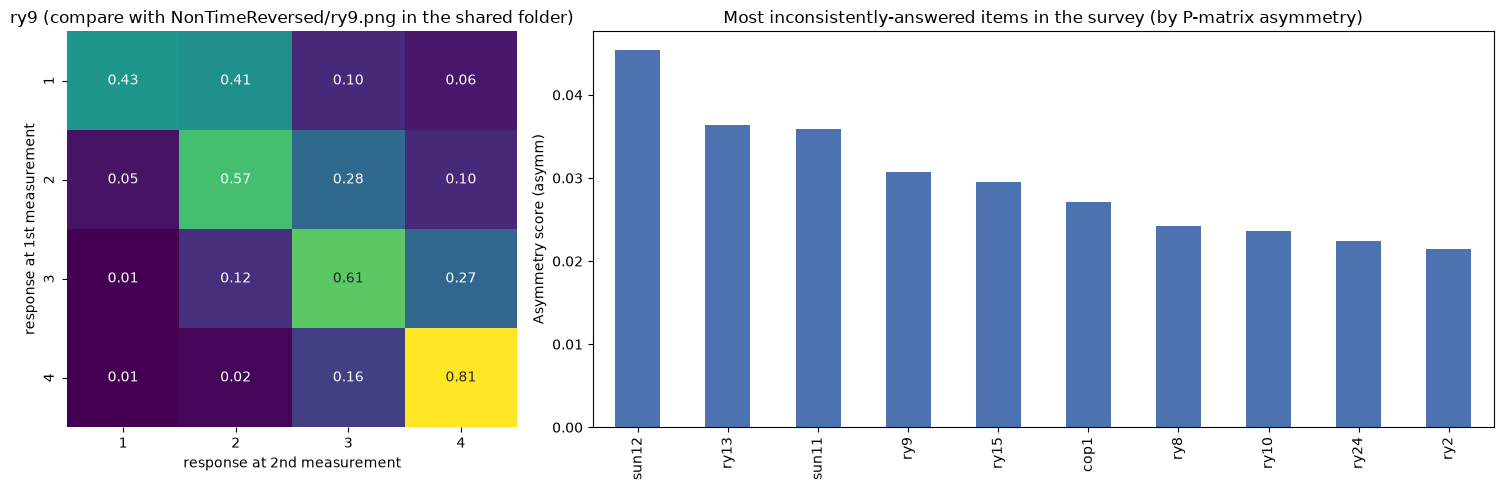

In [30]:
from scrp_toolkit.reliability import plot_asymmetry_bar, plot_p_matrix_heatmap

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
plot_p_matrix_heatmap(P[EXAMPLE_ITEM], title=f"{EXAMPLE_ITEM} (compare with NonTimeReversed/{EXAMPLE_ITEM}.png in the shared folder)", ax=ax[0])
plot_asymmetry_bar(score_asymmetry(P), ax=ax[1], top_n=10)
plt.tight_layout(); plt.show()

### Step 3b: Were the matrices recomputed, or just loaded?

**Loaded, not recomputed.** RYA estimated each matrix from students re-answering items (Technical Overview §2.4). That re-test data is **not** in Box: RY25 has no repeated-item columns and no student IDs. What we *can* do is check RYA's three copies of **P** against each other:

| Copy | Where | Used for |
|---|---|---|
| `unreliability-matrices.json` | Unreliability Matrices | portal / inference (what we load) |
| `P.RData` | Final code | the R simulation that generated the training data |
| `P_matrix` column | every row of the 4 training CSVs | what EXP002 was actually trained on (P plus a little random jitter) |

`P.RData` is read with the toolkit's own small R-file reader (`scrp_toolkit/rds.py`), so there's no extra package to install. The earlier version needed `rdata`, and pip couldn't install it on some machines.

**Expect:**
- `2 cells differ out of 1064`: `sun1` and `ry17`, row 2 col 1 (RData 0.08 vs JSON 0.07 / 0.09).
- Second cell (about 30 s): 53 items in the training data, no chs; training mean about 0.080 for both items, i.e. centred on the **RData** values.

In [9]:
P_R = load_p_rdata()
print(f"items: JSON {len(P)}, RData {len(P_R)}, same names: {set(P) == set(P_R)}")
n_diff = 0
for q in P:
    for i, j in np.argwhere(np.abs(P_R[q] - P[q]) > 1e-9):
        n_diff += 1
        print(f"  {q:5} row {i+1} col {j+1}:  RData {P_R[q][i, j]:.2f}   JSON {P[q][i, j]:.2f}"
              f"   (row sums: RData {P_R[q][i].sum():.2f}, JSON {P[q][i].sum():.2f})")
print(f"{n_diff} cells differ out of {sum(m.size for m in P.values())}")

items: JSON 59, RData 59, same names: True
  sun1  row 2 col 1:  RData 0.08   JSON 0.07   (row sums: RData 1.00, JSON 0.99)
  ry17  row 2 col 1:  RData 0.08   JSON 0.09   (row sums: RData 1.00, JSON 1.01)
2 cells differ out of 1064


In [10]:
P_R = load_p_rdata()          # re-loaded so this cell also runs on its own
csvs = sorted(glob.glob(os.path.join(paths.instance_dir, "*.csv")))
pm = pd.concat([pd.read_csv(f, usecols=["P_matrix", "P_matrix_question"]) for f in csvs])
to_P = lambda s: np.array(ast.literal_eval("[" + s[2:-1] + "]")).reshape(4, 4).T   # RYA's R_matrix_to_np

print(f"training rows: {len(pm):,}; items: {pm.P_matrix_question.nunique()} "
      f"(any chs? {pm.P_matrix_question.str.startswith('chs').any()})")
for q in ["sun1", "ry17", "ry9"]:
    M = np.stack([to_P(s) for s in pm.loc[pm.P_matrix_question == q, "P_matrix"]])
    print(f"{q:5} row 2 col 1: training mean {M[:, 1, 0].mean():.4f} (sd {M[:, 1, 0].std():.4f})"
          f" | RData {P_R[q][1, 0]:.2f} | JSON {P[q][1, 0]:.2f}")

training rows: 63,328; items: 53 (any chs? False)
sun1  row 2 col 1: training mean 0.0798 (sd 0.0045) | RData 0.08 | JSON 0.07
ry17  row 2 col 1: training mean 0.0799 (sd 0.0047) | RData 0.08 | JSON 0.09
ry9   row 2 col 1: training mean 0.0503 (sd 0.0047) | RData 0.05 | JSON 0.05


## Step 4: `features.py`, answer counts → the model's 40 inputs

**Why:** For one item and two groups (Pre = x, Post = y, counts of students per answer 1–4), `extract_features` builds the 40 numbers EXP002 was trained on:

| Features | Meaning |
|---|---|
| `X_1..4`, `Y_1..4` | share of each group picking each answer |
| `XmY_1..4` | absolute difference between the groups |
| `mean/stdev/skewness/kurtosis_X` and `_Y` | shape of each group's answers |
| `euclid_dist_XY` | overall distance between the groups (4 dp) |
| `n_X`, `n_Y` | group sizes |
| `P_0..P_15`, `asymm` | the item's unreliability matrix (Step 3) |

**Compared with recieved version:** two RYA implementations exist, and we check against both.
1. **Python**, `feature_calculation_portal_script.py` (portal scoring): RYA's functions (loaded in the SETUP) run side by side with ours.
2. **R**, `d_hat_simulation_from_LL.R` (wrote the training data) every training row stores R's features, which we recompute and compare.

**Expected Output:**
- **Cell 1:** same names & order, 40 features, `max difference: 0.0`; order matches `EXP002.json`.
- **Cell 2:** RYA's version silently accepts the 6-option item `chs1` (60 features, the model needs 40) while ours raises an error. Both return NaN when everyone gives the same answer, for the classifier to detect
- **Cell 3** : exactly **1 row** differs, `orthog_B_3_large_classes_2790`: 1 student in group Y but answer shares 0, 1, 1, 1.
- **Cell 4:** that one row sets **9 of EXP002's scaling limits** (e.g. `stdev_Y` max 10.49 instead of 1.50).

In [11]:
from scrp_toolkit.features import extract_features

theirs = rya["extract_features"](x, y, EXAMPLE_ITEM, "all_P_asymm")
ours = extract_features(x, y, EXAMPLE_ITEM, P)
print("RYA functions loaded:", [k for k, v in rya.items() if callable(v) and not k.startswith("_") and k not in ("np", "pd")])
print("same names & order:", list(theirs.index) == list(ours.index), f"| {len(ours)} features",
      "| max difference:", float(np.abs(theirs.values.astype(float) - ours.values.astype(float)).max()))
print("order matches EXP002.json feature_labels:", list(ours.index) == meta["feature_labels"])
display(pd.DataFrame({"RYA": theirs, "ours": ours}).head(23))

RYA functions loaded: ['moment_calculator', 'asymm_calc', 'transform_P_matrix', 'extract_features', 'normalise', 'reverse_normalise']
same names & order: True | 40 features | max difference: 0.0
order matches EXP002.json feature_labels: True


,RYA,ours
X_1,0.353982,0.353982
X_2,0.460177,0.460177
X_3,0.061947,0.061947
X_4,0.123894,0.123894
Y_1,0.097826,0.097826
Y_2,0.184783,0.184783
Y_3,0.586957,0.586957
Y_4,0.130435,0.130435
XmY_1,0.256156,0.256156
XmY_2,0.275394,0.275394


In [43]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
print("6-option item chs1:")
print("  RYA :", len(rya["extract_features"](x, y, "chs1", "all_P_asymm")), "features, no error (the model needs 40)")
try:
    extract_features(x, y, "chs1", P)
except ValueError as e:
    print("  ours: ValueError:", e)

same = np.array([100, 0, 0, 0])
print("\nEveryone gives the same answer (x = y = [100, 0, 0, 0]):")
print("  RYA  skewness_X =", rya["extract_features"](same, same, EXAMPLE_ITEM, "all_P_asymm")["skewness_X"])
print("  ours skewness_X =", extract_features(same, same, EXAMPLE_ITEM, P)["skewness_X"], " <- same NaN")

6-option item chs1:
  RYA : 60 features, no error (the model needs 40)
  ours: ValueError: Item 'chs1' has a 6x6 unreliability matrix; the EXP002 network only supports 4-option items (4x4).

Everyone gives the same answer (x = y = [100, 0, 0, 0]):
  RYA  skewness_X = nan
  ours skewness_X = nan  <- same NaN


In [13]:
cols = [c for c in meta["feature_labels"] if not c.startswith("P_") and c != "asymm"]   # the 23 R wrote
raw = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(os.path.join(paths.instance_dir, "*.csv")))])
train = raw.dropna()                              # RYA drops the 68 NaN rows too
if not CHECK_ALL_TRAINING_ROWS:
    train = pd.concat([train.sample(3000, random_state=0), train[train.exp_code == CORRUPT_ROW]])
print(f"training rows: {len(raw):,} raw, {len(raw.dropna()):,} after dropna, checking {len(train):,}")

t0, bad = time.time(), []
for r in train.itertuples():
    q = r.P_matrix_question
    f = extract_features(np.array([r.X_1, r.X_2, r.X_3, r.X_4]) * r.n_X,
                         np.array([r.Y_1, r.Y_2, r.Y_3, r.Y_4]) * r.n_Y, q, {q: P[q]})
    for c in cols:
        v = getattr(r, c)
        if abs(f[c] - v) > 1e-9 * max(1, abs(v)):
            bad.append((r.exp_code, c, v, f[c]))
bad = pd.DataFrame(bad, columns=["exp_code", "feature", "R value", "ours"])
print(f"compared in {time.time() - t0:.0f}s -> {bad.exp_code.nunique()} row(s) differ:", list(bad.exp_code.unique()))

row = raw[raw.exp_code == CORRUPT_ROW].iloc[0]
print(f"\nthat row: item {row.P_matrix_question}, n_Y = {row.n_Y}, Y shares = "
      f"{[float(v) for v in (row.Y_1, row.Y_2, row.Y_3, row.Y_4)]} (1 student, shares sum to 3)")

training rows: 63,328 raw, 63,260 after dropna, checking 63,260
compared in 42s -> 1 row(s) differ: ['orthog_B_3_large_classes_2790']

that row: item ry2, n_Y = 1, Y shares = [0.0, 1.0, 1.0, 1.0] (1 student, shares sum to 3)


In [14]:
row = raw[raw.exp_code == CORRUPT_ROW].iloc[0]
others = raw.dropna()
others = others[others.exp_code != CORRUPT_ROW]
limits = []
for c in cols:
    for stat in ("min", "max"):
        if np.isclose(stored_mm.loc[c, stat], row[c]) and not np.isclose(getattr(others[c], stat)(), row[c]):
            limits.append((c, stat, round(stored_mm.loc[c, stat], 4), round(getattr(others[c], stat)(), 4)))
display(pd.DataFrame(limits, columns=["feature", "limit", "EXP002.json (set by the bad row)", "without the bad row"]))

,feature,limit,EXP002.json (set by the bad row),without the bad row
0,Y_2,max,1.0000,0.9796
1,Y_3,max,1.0000,0.9412
2,Y_4,max,1.0000,0.9209
3,XmY_2,max,0.9988,0.9225
4,mean_Y,max,9.0000,3.9167
5,stdev_Y,max,10.4881,1.5000
6,kurtosis_Y,min,0.3572,1.0000
7,euclid_dist_XY,max,1.3882,1.1213
8,n_Y,min,1.0000,5.0000


**What the bad row means.** The model scales every input into 0–1 using the min/max in `EXP002.json` (Step 6). For 9 of those limits the value comes from this one corrupt row. For example, real `stdev_Y` never exceeds 1.5 but the stored max is 10.49, so real values get squeezed into 0–0.14.
- **Baseline:** unchanged. EXP002 was trained with these limits, so we must use them exactly as they are.
- **When Retraining/finetuning:** drop this row first.
- **For Input detector/classfier:** the real training range for group sizes is 5 and up, not 1.

## Step 5: `inference.py`, running RYA's trained model

**Why:** This produces the numbers everyone can use. It 
(1) scales the 40 features into 0–1 with `EXP002.json`, 
(2) runs the shipped **`EXP002_nn_optimal_epoch.onnx`** (not retrained) in the shared state, and 
(3) converts the 2 outputs back to **shape** and **rate**. These describe the Gamma distribution of the d̂ difference statistic that test-retest noise alone would produce. `shape / rate` is its mean.

| Ours (`UnreliabilityPredictor`) | Shared by RYA |
|---|---|
| `_normalise`, `_reverse_normalise` | `normalise()`, `reverse_normalise()` in `feature_calculation_portal_script.py` |
| scaling values | `EXP002.json["min_max_df"]` |
| ONNX input = a plain vector of 40 | `perform_exp.py` exported with a 1-D dummy input |

RYA's script body can't run on today's pandas (`pd.read_json(<text>)` and `float(<Series>)`), so cell 2 calls RYA's own `normalise`/`reverse_normalise` with plain numbers. The maths is unchanged. **Fix made at this step:** our reverse-normalisation now works in float64 like RYA's.

**Expect:**
- **Cell 1:** model summary; ONNX input `[40]`, output `[2]`.
- **Cell 2:** RYA path and ours: shape `9.970475608…`, rate `20.926446973…`, difference `0.0`.
- **Cell 3:** matches the recorded baseline; 113/92 and 1,130/920 students are inside the training range, while 11,300/9,200 is **outside** it (`n_X`).

In [15]:
inp, out = predictor.session.get_inputs()[0], predictor.session.get_outputs()[0]
print(predictor.describe())
print(f"ONNX input : name={inp.name!r} shape={inp.shape} type={inp.type}")
print(f"ONNX output: name={out.name!r} shape={out.shape}   -> [normalised shape, normalised rate]")

Model: 20 layers, width 256, 40 features, P_transform='all_P_asymm'
ONNX input : name='input.1' shape=[40] type=tensor(float)
ONNX output: name='125' shape=[2]   -> [normalised shape, normalised rate]


In [16]:
labels, mm = meta["feature_labels"], stored_mm
inp = predictor.session.get_inputs()[0]

# RYA's path, with their functions from the Box copy of feature_calculation_portal_script.py
feats = rya["extract_features"](x, y, EXAMPLE_ITEM, meta["P_transform"])
vec = np.array([rya["normalise"](feats[c], mm.loc[c, "min"], mm.loc[c, "max"]) for c in labels], dtype=np.float32)
raw_out = predictor.session.run(None, {inp.name: vec})[0]
rya_shape = rya["reverse_normalise"](raw_out[0], mm.loc["shape", "min"], mm.loc["shape", "max"])
rya_rate  = rya["reverse_normalise"](raw_out[1], mm.loc["rate", "min"],  mm.loc["rate", "max"])

our_shape, our_rate = predictor.predict(x, y, EXAMPLE_ITEM)
print(f"normalised inputs range {vec.min():.4f} .. {vec.max():.4f} (inside 0-1 = inside training range)")
print(f"raw ONNX output        {raw_out}")
print(f"RYA  : shape={rya_shape!r}  rate={rya_rate!r}")
print(f"ours : shape={our_shape!r}  rate={our_rate!r}")
print(f"difference: {abs(rya_shape - our_shape)}, {abs(rya_rate - our_rate)}   |  mean shape/rate = {our_shape / our_rate:.5f}")

normalised inputs range 0.0078 .. 0.9465 (inside 0-1 = inside training range)
raw ONNX output        [0.00353707 0.00886882]
RYA  : shape=9.970475608021188  rate=20.926446972942113
ours : shape=9.970475608021188  rate=20.926446972942113
difference: 0.0, 0.0   |  mean shape/rate = 0.47645


In [17]:
rec = json.load(open(RYA_BASELINE))["ry9_example"]
s0, r0 = predictor.predict(x, y, EXAMPLE_ITEM)
print(f"recorded baseline (ry9): shape={rec['shape']}  rate={rec['rate']}  -> match: "
      f"{np.isclose(s0, rec['shape'], atol=1e-6) and np.isclose(r0, rec['rate'], atol=1e-6)}")

labels = meta["feature_labels"]
rows = []
for scale in (1, 10, 100):
    xs, ys = x * scale, y * scale
    f = extract_features(xs, ys, EXAMPLE_ITEM, P).reindex(labels)
    norm = (f - stored_mm.loc[labels, "min"]) / (stored_mm.loc[labels, "max"] - stored_mm.loc[labels, "min"])
    s, r = predictor.predict(xs, ys, EXAMPLE_ITEM)
    rows.append({"n Pre": xs.sum(), "n Post": ys.sum(), "shape": round(s, 3), "rate": round(r, 3), "mean": round(s / r, 5),
                 "inputs outside training range": ", ".join(norm[(norm < 0) | (norm > 1)].index) or "none"})
display(pd.DataFrame(rows))

recorded baseline (ry9): shape=9.97047561  rate=20.92644697  -> match: True


,n Pre,n Post,shape,rate,mean,inputs outside training range
0,113,92,9.970,20.926,0.47645,none
1,1130,920,89.596,204.516,0.43809,none
2,11300,9200,113.961,330.128,0.34520,n_X


**Take-away:** `inference.py` reproduces RYA's scoring exactly. The model has no guard for inputs outside its training parameter range (group sizes 5 to 9,819 Pre inference / 9,940 Post inference): it still returns a number. That's another rule for input detector/classifier head.

## Step 6: `dataset.py`, rebuilding the training data exactly as RYA did

**Why:** The 84 scaling values in `EXP002.json` came from RYA's data preparation. If ours is identical, it reproduces them from the raw training CSVs, so anyone experimenting on our dataset is on RYA's footing. Nothing is retrained.

**Compared with shared code :** `Final code/net_dataset_init_B.py` → `D_hat_Dataset` (the version `perform_exp.py` imports, i.e. the one that trained EXP002). Cell 1 **runs RYA's actual class**, with two adapters that don't touch its logic:
- `os.listdir` / `os.path.join` point at your instance-data folder (RYA hard-coded `/Users/liam/...`),
- `float()` accepts a one-value pandas Series, as it did in 2022.

RYA's preparation: drop NaN rows → **rescale rate by 2/(1/n_X + 1/n_Y)** → expand P into P_0..P_15 + asymm → keep the first copy of each `exp_code` → min-max every column → drop the outer 1% of shape and rate → 80/20 split.

**Expected Output:**
- **Cell 1:** RYA's class → 48,924 training rows, 40 features; min/max vs `EXP002.json` differ by about 5e-11 at most; order identical.
- **Cell 2:** ours → 61,155 rows; identical training features and targets, min/max difference `0.0`.

In [18]:
mf = types.SimpleNamespace(**{k: v for k, v in load_rya("misc_functions.py",
        ["asymm_calc", "R_matrix_to_np", "P_matrix_transform"]).items() if callable(v)})
inst = paths.instance_dir
os_adapter = types.SimpleNamespace(listdir=lambda _: sorted(os.listdir(inst)),
                                   path=types.SimpleNamespace(join=lambda _, f: os.path.join(inst, f)))
float_adapter = lambda v: builtins.float(v.iloc[0] if hasattr(v, "iloc") else v)
ndi = load_rya("net_dataset_init_B.py", ["D_hat_Dataset"],
               {"mf": mf, "os": os_adapter, "float": float_adapter, "Dataset": torch.utils.data.Dataset})

EXP002_SETTINGS = dict(two_sided_outlier_percentage=1, log_output_data_true=False, include_XY_dist=True,
                       XY_symm_true=False, train_frac=TRAIN_FRAC, include_skwurtoses_true=True,
                       P_transform="all_P_asymm", B_transform_true=False,
                       local_test_dict={"is_local": True, "test_run": False})
t0 = time.time()
rya_train = ndi["D_hat_Dataset"](is_train=True, random_seed=SPLIT_SEED, **EXP002_SETTINGS)
print(f"RYA's D_hat_Dataset: {len(rya_train):,} training rows, {len(rya_train.feature_columns)} features ({time.time() - t0:.0f}s)")

rya_mm = rya_train.min_max_col_df
st = stored_mm.reset_index()
print("columns identical to EXP002.json:", list(rya_mm.column) == list(st.column))
print("largest min/max difference vs EXP002.json:",
      max(np.abs(rya_mm["min"] - st["min"]).max(), np.abs(rya_mm["max"] - st["max"]).max()))
print("feature order identical to EXP002.json:", list(rya_train.feature_columns) == meta["feature_labels"])

RYA's D_hat_Dataset: 48,924 training rows, 40 features (11s)
columns identical to EXP002.json: True
largest min/max difference vs EXP002.json: 4.959488375533283e-11
feature order identical to EXP002.json: True


In [42]:
from scrp_toolkit.dataset import build_preprocessed_dataset, train_test_split_like_original

df, feature_cols, our_mm = build_preprocessed_dataset(paths.instance_dir)
tr, te = train_test_split_like_original(df, train_frac=TRAIN_FRAC, random_seed=SPLIT_SEED)
print(f"ours: {len(df):,} rows after preparation -> {len(tr):,} train / {len(te):,} test")
if "rya_train" in globals():
    print("training features identical to RYA's:", np.array_equal(tr[feature_cols].to_numpy(float), rya_train.df_features.to_numpy(float)))
    print("training targets  identical to RYA's:", np.array_equal(tr[["shape", "rate"]].to_numpy(float), rya_train.df_output.to_numpy(float)))
    print("min/max difference ours vs RYA:",
          float(np.abs(our_mm[["min", "max"]].to_numpy() - rya_train.min_max_col_df[["min", "max"]].to_numpy()).max()))
print("min/max difference ours vs EXP002.json:",
      float(np.abs(our_mm.set_index("column")[["min", "max"]].to_numpy() - stored_mm[["min", "max"]].to_numpy()).max()))

df_nb, _, mm_nb = build_preprocessed_dataset(paths.instance_dir, normalise_rate=False)
r, s = mm_nb.set_index("column").loc["rate"], stored_mm.loc["rate"]
print("\nNote: RYA drew EXP002's split seed at random (perform_exp.py: np.random.randint(100)) and never saved it,")
print(f"so SPLIT_SEED={SPLIT_SEED} reproduces RYA's *procedure*, not EXP002's exact train/test rows.\nNeed to confirm exact seed state with RYA to reproduce EXP002's train/test split. The 68 rows with NaN features are dropped in the training set, but they remain in the test set.")

ours: 61,155 rows after preparation -> 48,924 train / 12,231 test
training features identical to RYA's: True
training targets  identical to RYA's: True
min/max difference ours vs RYA: 0.0
min/max difference ours vs EXP002.json: 4.959488375533283e-11

Note: RYA drew EXP002's split seed at random (perform_exp.py: np.random.randint(100)) and never saved it,
so SPLIT_SEED=42 reproduces RYA's *procedure*, not EXP002's exact train/test rows.
Need to confirm exact seed state with RYA to reproduce EXP002's train/test split. The 68 rows with NaN features are dropped in the training set, but they remain in the test set.


## Step 7: `model.py`, the network and its training loss

**Why:** Retraining or shrinking the model must start from exactly RYA's network and loss. The trained weights are inside the ONNX file, so loading them into our `Net` and getting identical outputs proves it's the same network.

| Ours | Box |
|---|---|
| `Net(n_features, n_layers, width)` | `Net` in `net_dataset_init_B.py` (EXP002: 40 inputs, 20 layers, width 256) |
| `K`, `KL` (Gamma KL loss + squared-error penalty for negative predictions) | `K`, `KL` in `misc_functions.py`, run side by side below |
| weights | `EXP002_nn_optimal_epoch.onnx` (exported by PyTorch 1.7) |

**Expected Output:**
- **Cell 1:** ONNX = 21 MatMul + 21 Add + 20 Relu; 1,261,058 parameters; ONNX vs our `Net` on 1,000 random inputs: `0.0`.
- **Cell 2:** RYA's `KL` vs ours on 5,000 rows (about 480 using the negative-prediction penalty): `0.0`.

In [20]:
import onnx
from onnx import numpy_helper
from collections import Counter
from scrp_toolkit.model import Net

graph = onnx.load(paths.onnx_path).graph
weights = {w.name: numpy_helper.to_array(w) for w in graph.initializer}
print("ONNX layers:", dict(Counter(n.op_type for n in graph.node)))

net = Net(n_features=len(meta["feature_labels"]), n_layers=meta["n_layers"], width=meta["width"]).eval()
linears = [m for m in net.linear_relu_stack if isinstance(m, torch.nn.Linear)]
W = [weights[n.input[1]] for n in graph.node if n.op_type == "MatMul"]
B = [weights[[i for i in n.input if i in weights][0]] for n in graph.node if n.op_type == "Add"]
for lin, w, b in zip(linears, W, B):
    lin.weight.data, lin.bias.data = torch.tensor(w.T.copy()), torch.tensor(b.copy())
print(f"our Net: {len(linears)} linear layers, {sum(p.numel() for p in net.parameters()):,} parameters")

in_name = predictor.session.get_inputs()[0].name
X = np.random.default_rng(0).random((1000, 40)).astype(np.float32)
onnx_out = np.stack([predictor.session.run(None, {in_name: v})[0] for v in X])
with torch.no_grad():
    net_out = net(torch.tensor(X)).numpy()
print("max difference ONNX vs our Net:", float(np.abs(onnx_out - net_out).max()))

ONNX layers: {'MatMul': 21, 'Add': 21, 'Relu': 20}
our Net: 21 linear layers, 1,261,058 parameters
max difference ONNX vs our Net: 8.940696716308594e-08


In [21]:
from scrp_toolkit.model import KL as our_KL

rya_KL = load_rya("misc_functions.py", ["K", "KL"])["KL"]
srmm = {"shape_min": stored_mm.loc["shape", "min"], "shape_max": stored_mm.loc["shape", "max"],
        "rate_min": stored_mm.loc["rate", "min"],   "rate_max": stored_mm.loc["rate", "max"]}
g = torch.Generator().manual_seed(0)
pred_n = torch.rand(5000, 2, generator=g) * 0.05 - 0.005        # some predictions below zero on purpose
true_n = torch.rand(5000, 2, generator=g) * 0.05
a = rya_KL(srmm, pred_n.clone(), true_n.clone(), reduce_mean=False)
b = our_KL(srmm, pred_n.clone(), true_n.clone(), reduce_mean=False)
neg = int(((srmm["shape_max"] - srmm["shape_min"]) * pred_n[:, 0] + srmm["shape_min"] < 0).sum())
print(f"mean loss RYA {a.mean().item():.6f} | ours {b.mean().item():.6f} | per-row max difference {(a - b).abs().max().item()}"
      f" | rows using the negative-prediction penalty: {neg}")

mean loss RYA 5632.123047 | ours 5632.123047 | per-row max difference 0.0 | rows using the negative-prediction penalty: 481


## Step 8: `scoring.py`, scoring a real RY25 school

**Why:** This is the real use. For one school, count answers 1–4 per item at Pre and Post, then score every item. Training only covers single-class/school sizes (up to about 9,900), so we score one school: the one with the largest Pre/Post overlap.

**Compared with shared code:** input = `Data/RY25_PreMay10.csv` + `RY25_PostMay10.csv` (verified in Step 2). Box has no survey-scoring script (that's in the portal), so we compare against the **recorded baseline**.

**Expected Output:** school `f7a2542b…491`, Pre 656 / Post 123; **40 items** (46 in both files minus the 6 `chs` items EXP002 can't score); identical to the baseline. A bar chart topped by `ry16` (0.0808), lowest `ph4` (0.0133).

Read `gamma_mean` as: *how big a Pre-vs-Post difference test-retest noise alone would typically produce for this item at these group sizes*. A real change has to clearly beat it.

school f7a2542b55bd29aa76cdf00c77805491: 40 items scored (1s)
vs recorded RYA baseline: 40 items, values identical: True, group sizes identical: True
chs items scored: none (correct)


,question,n_pre,n_post,shape_hat,rate_hat,gamma_mean,asymm
0,ry16,656,123,4.706181,58.231701,0.080818,0.000600
1,ry10,656,123,3.328148,57.664258,0.057716,0.023567
2,phq4,388,67,1.656249,36.765339,0.045049,0.008550
3,ry25,388,67,1.653218,38.276231,0.043192,0.004600
4,ry20,388,67,1.611199,42.573039,0.037846,0.008233


,question,n_pre,n_post,shape_hat,rate_hat,gamma_mean,asymm
37,ry21,656,123,1.606737,96.354163,0.016675,0.010317
38,ry11,656,123,1.500381,105.588023,0.014210,0.015983
39,ph4,656,123,1.501233,113.130211,0.013270,0.003850


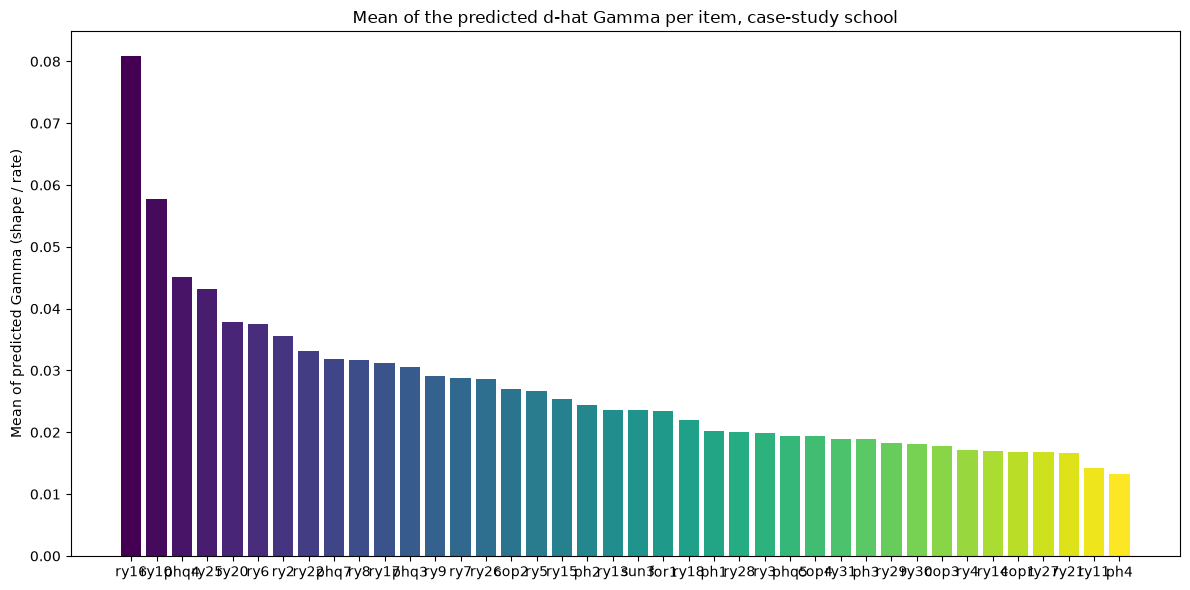

In [41]:
from scrp_toolkit.scoring import score_school, plot_scores_bar
from scrp_toolkit.baseline import MURAT_REFERENCE

t0 = time.time()
scores = score_school(predictor, paths)
print(f"school {scores.attrs['school']}: {len(scores)} items scored ({time.time() - t0:.0f}s)")

def compare(ref_items, label):
    ref = pd.DataFrame(ref_items).set_index("question")
    got = scores.set_index("question").loc[ref.index]
    c = [k for k in ("shape_hat", "rate_hat", "gamma_mean", "asymm") if k in ref]
    ok = np.isclose(got[c].to_numpy(float), ref[c].to_numpy(float), rtol=1e-5, atol=1e-6).all()
    same_n = (got[["n_pre", "n_post"]].to_numpy() == ref[["n_pre", "n_post"]].to_numpy()).all()
    print(f"vs {label}: {len(ref)} items, values identical: {ok}, group sizes identical: {same_n}")

compare(json.load(open(RYA_BASELINE))["case_study"]["items"], "recorded RYA baseline")
print("chs items scored:", [q for q in scores.question if q.startswith("chs")] or "none (correct)")
display(scores.head(5)); display(scores.tail(3))
plot_scores_bar(scores); plt.tight_layout(); plt.show()

## Step 9: everything at once (`cli.py`, `baseline.py`, tests, `edge_cases.py`)

**Why:** This is what each teammate runs after getting the repo: one command that repeats Steps 2–8 as **359 checks**. Experiments are judged by what changes in `baseline_report.csv`.

From a terminal (Anaconda Prompt, `conda activate scrp`, in the repo root) it's simply:
```
python -m scrp_toolkit.cli baseline
```
(`--project-root` is optional: it defaults to `SCRP_DATA`, else `./data`.)

**Expect (about 2–3 min):**
- **Cell 1:** `[PASS]` files 9/9, explore 13/13, model 1/1, ry9 3/3, case_study 242/242, scaling 86/86, dataset 5/5 → `TOTAL: 359/359 … BASELINE MATCHES`
- **Cell 2:** `33 passed`
- **Cell 3:** 8 edge cases; `all_same_option`, `single_respondent`, `empty_group` flagged; `unknown_question_code` correctly rejected
- **Cell 4:** optional training demo (off unless `RUN_TRAINING_DEMO = True` in SETTINGS)

In [23]:
cmd = [sys.executable, "-m", "scrp_toolkit.cli", "baseline", "--project-root", DATA, "--report", str(REPORT_CSV)]
res = subprocess.run(cmd, capture_output=True, text=True, cwd=REPO_DIR)
print(res.stdout[-2500:] or res.stderr[-2500:])
print("exit code:", res.returncode, "(0 = baseline matches)")

Checking against: rya_baseline.json
[PASS] files       9/9 checks passed
[PASS] explore     13/13 checks passed
[PASS] model       1/1 checks passed
[PASS] ry9         3/3 checks passed
[PASS] case_study  242/242 checks passed
[PASS] scaling     86/86 checks passed
[PASS] dataset     5/5 checks passed

TOTAL: 359/359 checks passed -> BASELINE MATCHES
Full report: D:\Desktop\Academics\Sem-2-26\Claude\scrp-toolkit\baseline_report.csv

exit code: 0 (0 = baseline matches)


In [24]:
res = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "tests"],
                     capture_output=True, text=True, cwd=REPO_DIR)
print(res.stdout.strip().splitlines()[-1] if res.stdout.strip() else res.stderr[-1500:])

33 passed, 5 warnings in 6.76s


In [25]:
res = subprocess.run([sys.executable, "-m", "scrp_toolkit.cli", "gen-edge-cases", "--project-root", DATA,
                      "--check-response-cases", "--out-dir", str(EDGE_CASE_DIR)], capture_output=True, text=True, cwd=REPO_DIR)
report = pd.read_csv(EDGE_CASE_DIR / "response_count_case_report.csv")
display(report[["label", "expect_failure", "raised", "produced_nan", "matches_expectation"]])

,label,expect_failure,raised,produced_nan,matches_expectation
0,all_same_option,False,False,True,False
1,single_respondent,False,False,True,False
2,unpicked_category,False,False,False,True
3,complete_reversal,False,False,False,True
4,mismatched_sample_sizes,False,False,False,True
5,extreme_skew,False,False,False,True
6,empty_group,True,False,True,False
7,unknown_question_code,True,True,False,True


In [26]:
if RUN_TRAINING_DEMO:
    res = subprocess.run([sys.executable, "-m", "scrp_toolkit.cli", "compare", "--project-root", DATA, "--quick-demo"],
                         capture_output=True, text=True, cwd=REPO_DIR)
    print(res.stdout[-1500:] or res.stderr[-1500:])
else:
    print("skipped: set RUN_TRAINING_DEMO = True in SETTINGS to run")

skipped: set RUN_TRAINING_DEMO = True in SETTINGS to run


## Summary

| Step | Result on the customer's data |
|---|---|
| 2 | 9/9 input files byte-identical to Box |
| 3 | asymm identical to RYA's on all 59 items; ry9 heatmap matches Box |
| 3b | P not recomputable (no re-test data in Box); JSON vs P.RData differ in 2 cells (`sun1`, `ry17`) |
| 4 | features identical to RYA's portal script (0.0) and to R's training features (1 corrupt row found) |
| 5 | model outputs identical to RYA's scoring path (0.0) |
| 6 | RYA's own data preparation reproduces EXP002.json; ours is identical to RYA's |
| 7 | our `Net` = the ONNX network (0.0); our loss = RYA's (0.0) |
| 8 | 40-item school scores identical to baseline |
| 9 | 359/359 baseline checks, 33/33 tests |

Open questions for RYA and team findings: `README.md` and `docs/findings.md`.